# Import data

In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

df = pd.read_csv('Adi_1.csv')
# Get all unique players
all_players = df[['Player']].drop_duplicates()

#Serve

## Ace and DF

In [214]:
# @title
# Count aces
aces = df.groupby('Point').filter(
    lambda x: len(x) == 1 and
              (x['Type'] == 'first_serve').any() and
              (x['Result'] == 'In').any()
)
ace_counts = aces.groupby('Player').size().reset_index(name='Aces')

# Count double faults
double_faults = df[(df['Type'] == 'second_serve') & (df['Result'] != 'In')]
df_counts = double_faults.groupby('Player').size().reset_index(name='Double_Faults')


##Serves %

In [215]:
# First serve percentage
first_serves = df[df['Type'] == 'first_serve'].groupby('Player')
first_serve_pct = (first_serves.apply(lambda x: (x['Result'] == 'In').sum() / len(x) * 100)
                  .reset_index(name='First_Serve_%'))

# Second serve percentage
second_serves = df[df['Type'] == 'second_serve'].groupby('Player')
second_serve_pct = (second_serves.apply(lambda x: (x['Result'] == 'In').sum() / len(x) * 100)
                   .reset_index(name='Second_Serve_%'))


/tmp/ipython-input-3156218693.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_serve_pct = (first_serves.apply(lambda x: (x['Result'] == 'In').sum() / len(x) * 100)
/tmp/ipython-input-3156218693.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  second_serve_pct = (second_serves.apply(lambda x: (x['Result'] == 'In').sum() / len(x) * 100)


## First/Second Serve Won%


In [216]:
# First serve won % - points where first serve went In, did the server win?
first_serve_in = df[(df['Type'] == 'first_serve') & (df['Result'] == 'In')]
first_serve_won = (first_serve_in.groupby('Player')
                   .apply(lambda x: (x['Winner'] == x['Player']).sum() / len(x) * 100)
                   .reset_index(name='First_Serve_Won_%'))

# Second serve won % - points where second serve went In, did the server win?
second_serve_in = df[(df['Type'] == 'second_serve') & (df['Result'] == 'In')]
second_serve_won = (second_serve_in.groupby('Player')
                    .apply(lambda x: (x['Winner'] == x['Player']).sum() / len(x) * 100)
                    .reset_index(name='Second_Serve_Won_%'))

/tmp/ipython-input-2657523908.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['Winner'] == x['Player']).sum() / len(x) * 100)
/tmp/ipython-input-2657523908.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['Winner'] == x['Player']).sum() / len(x) * 100)


# Serve Summary

In [217]:
# @title
summary_serve = all_players.merge(ace_counts, on='Player', how='left')
summary_serve = summary_serve.merge(df_counts, on='Player', how='left')
summary_serve = summary_serve.merge(first_serve_pct, on='Player', how='left')
summary_serve = summary_serve.merge(second_serve_pct, on='Player', how='left')
summary_serve = summary_serve.merge(first_serve_won, on='Player', how='left')
summary_serve = summary_serve.merge(second_serve_won, on='Player', how='left')
summary_serve = summary_serve.fillna(0)
summary_serve[['Aces', 'Double_Faults']] = summary_serve[['Aces', 'Double_Faults']].astype(int)
summary_serve[['First_Serve_%', 'Second_Serve_%',
         'First_Serve_Won_%', 'Second_Serve_Won_%']] = summary_serve[['First_Serve_%', 'Second_Serve_%',
                                                                  'First_Serve_Won_%', 'Second_Serve_Won_%']].round(1)
print(summary_serve)

       Player  Aces  Double_Faults  First_Serve_%  Second_Serve_%  \
0  Adi Bitton     0              6           64.2            79.3   
1    Opponent     0              2           60.0            93.3   

   First_Serve_Won_%  Second_Serve_Won_%  
0               61.5                52.2  
1               55.6                35.7  


In [218]:
# @title
# Points where a player has exactly 2 shots: first_serve and serve_plus_one
two_shot_serve_points = df.groupby('Point').filter(
    lambda x: len(x[x['Player'] == x['Player'].iloc[0]]) == 2 and
              set(x[x['Player'] == x['Player'].iloc[0]]['Type']) == {'first_serve', 'serve_plus_one'}
)

# Get unique points and the server
serve_points_summary = []
for point in two_shot_serve_points['Point'].unique():
    point_data = two_shot_serve_points[two_shot_serve_points['Point'] == point]
    server = point_data[point_data['Type'] == 'first_serve']['Player'].iloc[0]
    winner = point_data['Winner'].iloc[0]

    serve_points_summary.append({
        'Point': point,
        'Server': server,
        'Winner': winner
    })

two_shot_df = pd.DataFrame(serve_points_summary)

# Count by player
player_stats = []
for player in df['Player'].unique():
    player_points = two_shot_df[two_shot_df['Server'] == player]
    total = len(player_points)
    won = (player_points['Winner'] == player).sum()
    win_pct = (won / total * 100).round(1) if total > 0 else 0

    player_stats.append({
        'Player': player,
        "Serve and one": f"{won}/{total} ({win_pct}%)"
    })

result_df = pd.DataFrame(player_stats)
print(result_df.to_string(index=False))


    Player Serve and one
Adi Bitton 10/20 (50.0%)
  Opponent  7/16 (43.8%)


#Returns

##Return Winner

In [219]:
# @title
# Return winners - when first_return or second_return is In AND it's the last shot of the point
# Get the last shot of each point
last_shots = df.groupby('Point').last().reset_index()

# Filter for return winners (last shot is a return and Result = In)
return_winners = last_shots[
    (last_shots['Type'].isin(['first_return', 'second_return'])) &
    (last_shots['Result'] == 'In')
]

return_winner_counts = return_winners.groupby('Player').size().reset_index(name='Return_Winners')


## Great Return that Forced Errors

In [220]:
# Return forced errors - returner forces the next shot to be missed (same point only)
df['Next_Result'] = df['Result'].shift(-1)
df['Next_Point'] = df['Point'].shift(-1)

return_forced_errors = df[
    (df['Type'].isin(['first_return', 'second_return'])) &
    (df['Next_Result'] != 'In') &
    (df['Next_Point'] == df['Point'])  # must be same point
]

rfe_counts = return_forced_errors.groupby('Player').size().reset_index(name='Return_Forced_Errors')


## Second Serve Return Missed

In [221]:
# Second serve return missed - when second_return is not In
second_return_missed = df[
    (df['Type'] == 'second_return') &
    (df['Result'] != 'In')
]
srm_counts = second_return_missed.groupby('Player').size().reset_index(name='Second_Return_Missed')

##Return Won%

In [222]:
# First return won % - points where player hit a first_return, did they win?
first_return_points = df[df['Type'] == 'first_return']
first_return_won = (first_return_points.groupby('Player')
                    .apply(lambda x: (x['Winner'] == x['Player']).sum() / len(x) * 100)
                    .reset_index(name='First_Return_Won_%'))

# Second return won % - points where player hit a second_return, did they win?
second_return_points = df[df['Type'] == 'second_return']
second_return_won = (second_return_points.groupby('Player')
                     .apply(lambda x: (x['Winner'] == x['Player']).sum() / len(x) * 100)
                     .reset_index(name='Second_Return_Won_%'))



/tmp/ipython-input-2258407695.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['Winner'] == x['Player']).sum() / len(x) * 100)
/tmp/ipython-input-2258407695.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['Winner'] == x['Player']).sum() / len(x) * 100)


#Return Summary

In [223]:
# @title
# Merge everything
return_summary = all_players.merge(return_winner_counts, on='Player', how='left')
return_summary = return_summary.merge(rfe_counts, on='Player', how='left')
return_summary = return_summary.merge(srm_counts, on='Player', how='left')
return_summary = return_summary.merge(first_return_won, on='Player', how='left')
return_summary = return_summary.merge(second_return_won, on='Player', how='left')
return_summary = return_summary.fillna(0)
return_summary[['Return_Winners', 'Return_Forced_Errors', 'Second_Return_Missed']] = \
    return_summary[['Return_Winners', 'Return_Forced_Errors', 'Second_Return_Missed']].astype(int)
return_summary[['First_Return_Won_%', 'Second_Return_Won_%']] = \
    return_summary[['First_Return_Won_%', 'Second_Return_Won_%']].round(1)

print(return_summary)

       Player  Return_Winners  Return_Forced_Errors  Second_Return_Missed  \
0  Adi Bitton               3                     9                     5   
1    Opponent               5                    14                     1   

   First_Return_Won_%  Second_Return_Won_%  
0                56.6                 72.4  
1                38.5                 48.0  


#Rally

##Winners

In [224]:
# Winners - last shot of point is In and Stroke is not Serve
winners = last_shots[
    (last_shots['Result'] == 'In') &
    (last_shots['Stroke'] != 'Serve')
]

winner_counts = winners.groupby('Player').size().reset_index(name='Winners')

##Unforced Errors

In [225]:
# Calculate average speed per player per stroke (excluding Serve)
avg_speeds = (df[df['Stroke'] != 'Serve']
              .groupby(['Player', 'Stroke'])['Speed (MPH)']
              .mean()
              .reset_index()
              .rename(columns={'Speed (MPH)': 'Avg_Speed'}))

# Get previous shot info
df['Prev_Player'] = df['Player'].shift(1)
df['Prev_Stroke'] = df['Stroke'].shift(1)
df['Prev_Speed'] = df['Speed (MPH)'].shift(1)
df['Prev_Point'] = df['Point'].shift(1)

# Merge with average speeds for the previous shot
df_with_avg = df.merge(
    avg_speeds,
    left_on=['Prev_Player', 'Prev_Stroke'],
    right_on=['Player', 'Stroke'],
    how='left',
    suffixes=('', '_prev')
)

# Unforced errors: current shot missed (Result != In),
# Stroke != Serve, previous shot was by opponent, same point,
# and previous shot speed < their average for that stroke
unforced_errors = df_with_avg[
    (df_with_avg['Result'] != 'In') &
    (df_with_avg['Stroke'] != 'Serve') &
    (df_with_avg['Prev_Player'] != df_with_avg['Player']) &
    (df_with_avg['Prev_Point'] == df_with_avg['Point']) &
    (df_with_avg['Prev_Speed'] < df_with_avg['Avg_Speed']) &
    (df_with_avg['Prev_Stroke'] != 'Serve')  # exclude if previous was serve
]

ue_counts = unforced_errors.groupby('Player').size().reset_index(name='Unforced_Errors')

##Net Points Won

In [226]:
# Winners - last shot of point is In and Stroke is not Serve
winners = last_shots[
    (last_shots['Result'] == 'In') &
    (last_shots['Stroke'] != 'Serve')
]
winner_counts = winners.groupby('Player').size().reset_index(name='Winners')

# Net Point Won% - points where player had a Volley or Overhead, did they win?
net_points = df[df['Stroke'].isin(['Volley', 'Overhead'])]
net_point_stats = (net_points.groupby('Player')
                   .apply(lambda x: pd.Series({
                       'Net_Won': (x['Winner'] == x['Player']).sum(),
                       'Net_Total': len(x)
                   }))
                   .reset_index())

net_point_stats['Net_Point_Won_%'] = (
    net_point_stats['Net_Won'].astype(int).astype(str) + '/' +
    net_point_stats['Net_Total'].astype(int).astype(str) + ' (' +
    (net_point_stats['Net_Won'] / net_point_stats['Net_Total'] * 100).round(1).astype(str) + '%)'
)

/tmp/ipython-input-3171905255.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


##All Points Won

In [227]:
# All Points Won
total_points = df.groupby('Point')['Winner'].first().reset_index()
all_points_total = len(total_points)

all_points_won = (total_points.groupby('Winner')
                  .size()
                  .reset_index(name='Points_Won')
                  .rename(columns={'Winner': 'Player'}))

all_points_won['All_Points_Won'] = (
    all_points_won['Points_Won'].astype(str) + '/' +
    str(all_points_total) + ' (' +
    (all_points_won['Points_Won'] / all_points_total * 100).round(1).astype(str) + '%)'
)


#Rally Summary

In [228]:
# @title
# Merge everything
winners_summary = all_players.merge(winner_counts, on='Player', how='left')
winners_summary = winners_summary.merge(net_point_stats[['Player', 'Net_Point_Won_%']], on='Player', how='left')
winners_summary = winners_summary.merge(all_points_won[['Player', 'All_Points_Won']], on='Player', how='left')
winners_summary = winners_summary.fillna(0)
winners_summary['Winners'] = winners_summary['Winners'].astype(int)
winners_summary = winners_summary.merge(ue_counts, on='Player', how='left').fillna(0)
winners_summary['Unforced_Errors'] = winners_summary['Unforced_Errors'].astype(int)

print(winners_summary)

       Player  Winners Net_Point_Won_%  All_Points_Won  Unforced_Errors
0  Adi Bitton       30    5/12 (41.7%)  88/166 (53.0%)               18
1    Opponent       18     0/10 (0.0%)  78/166 (47.0%)               18


#Speed

In [229]:
# @title
# Speed distribution by Stroke (excluding Serve)
def speed_summary(player):
    player_df = df[df['Player'] == player]

    stroke_speed = (player_df[player_df['Stroke'] != 'Serve']
                    .groupby('Stroke')['Speed (MPH)']
                    .agg(
                        Count='count',
                        Mean='mean',
                        Min='min',
                        Max='max'
                    )
                    .round(1)
                    .reset_index())

    serve_speed = (player_df[player_df['Stroke'] == 'Serve']
                   .groupby('Type')['Speed (MPH)']
                   .agg(
                       Count='count',
                       Mean='mean',
                       Min='min',
                       Max='max'
                   )
                   .round(1)
                   .reset_index()
                   .rename(columns={'Type': 'Stroke'}))

    summary = pd.concat([serve_speed, stroke_speed], ignore_index=True)
    return summary

for player in df['Player'].unique():
    print(f"  {player}")
    print(speed_summary(player).to_string(index=False))


  Adi Bitton
      Stroke  Count  Mean  Min  Max
 first_serve     81  59.4 30.4 91.0
second_serve     29  54.0 25.7 66.4
    Backhand    162  48.1 25.3 71.9
    Forehand    159  48.3 23.6 73.7
    Overhead      4  54.5 22.5 77.8
      Volley      8  21.5 18.2 23.7
  Opponent
      Stroke  Count  Mean  Min   Max
 first_serve     90  69.6 29.1 130.6
second_serve     30  58.8 32.6  78.9
    Backhand    127  47.0 21.9  76.1
    Forehand    187  48.7 13.8  82.0
      Volley     10  20.6 16.7  23.4


##Distribution Visual

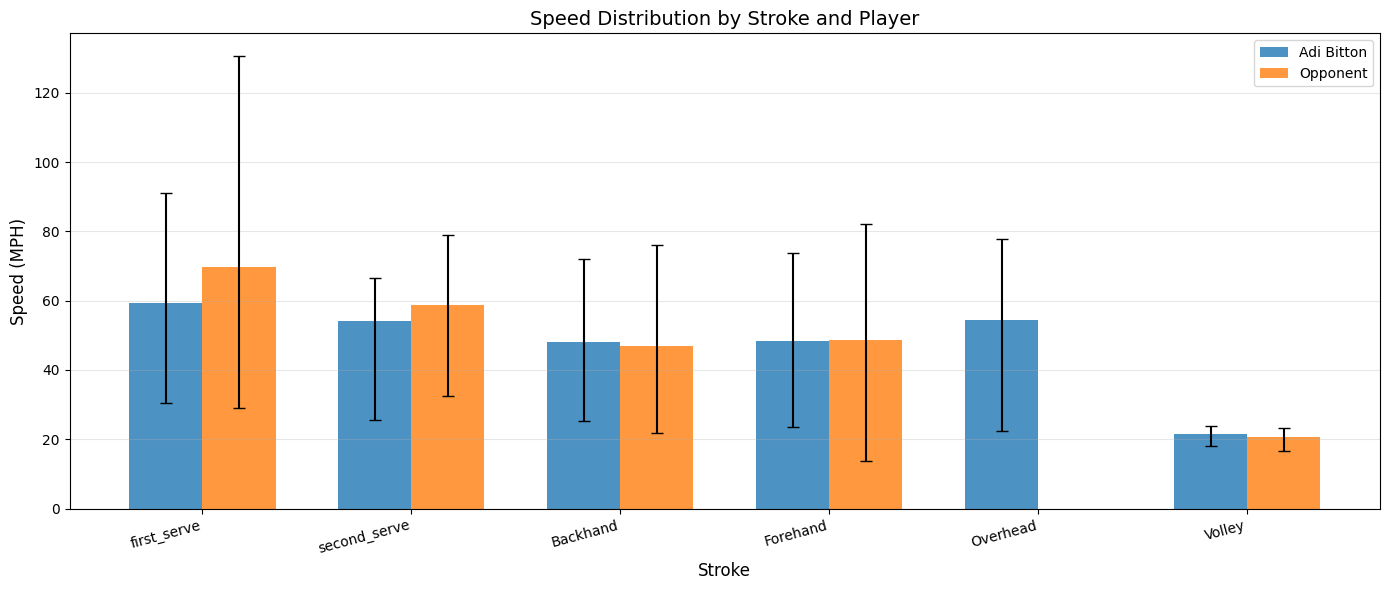

In [230]:
# @title

# Prepare data for both players
all_strokes = []

for player in df['Player'].unique():
    player_df = df[df['Player'] == player]

    # Serves
    serve_stats = (player_df[player_df['Stroke'] == 'Serve']
                   .groupby('Type')['Speed (MPH)']
                   .agg(Mean='mean', Min='min', Max='max')
                   .round(1)
                   .reset_index()
                   .rename(columns={'Type': 'Stroke'}))

    # Rally strokes
    rally_stats = (player_df[player_df['Stroke'] != 'Serve']
                   .groupby('Stroke')['Speed (MPH)']
                   .agg(Mean='mean', Min='min', Max='max')
                   .round(1)
                   .reset_index())

    combined = pd.concat([serve_stats, rally_stats], ignore_index=True)
    combined['Player'] = player
    all_strokes.append(combined)

plot_df = pd.concat(all_strokes, ignore_index=True)

# Plot
strokes = plot_df['Stroke'].unique()
players = plot_df['Player'].unique()
x = np.arange(len(strokes))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

for i, player in enumerate(players):
    player_data = plot_df[plot_df['Player'] == player].set_index('Stroke').reindex(strokes)
    offset = (i - 0.5) * width

    bars = ax.bar(x + offset, player_data['Mean'], width, label=player, alpha=0.8)

    # Error bars showing min/max
    ax.errorbar(
        x + offset,
        player_data['Mean'],
        yerr=[player_data['Mean'] - player_data['Min'],
              player_data['Max'] - player_data['Mean']],
        fmt='none', color='black', capsize=4, linewidth=1.5
    )

ax.set_xlabel('Stroke', fontsize=12)
ax.set_ylabel('Speed (MPH)', fontsize=12)
ax.set_title('Speed Distribution by Stroke and Player', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(strokes, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#Rally Outcome


##Rally shots distribution


In [231]:
# Count shots per point
shots_per_point = df.groupby('Point').size().reset_index(name='Shot_Count')

# Add winner info
point_winner = df.groupby('Point')['Winner'].first().reset_index()
shots_per_point = shots_per_point.merge(point_winner, on='Point')

total_points = len(shots_per_point)

# Calculate distribution with percentages
shot_distribution = pd.DataFrame({
    'Category': ['1 shot', '2 shots', '3 shots', '4 shots', '5-6 shots', '7+ shots'],
    'Count': [
        (shots_per_point['Shot_Count'] == 1).sum(),
        (shots_per_point['Shot_Count'] == 2).sum(),
        (shots_per_point['Shot_Count'] == 3).sum(),
        (shots_per_point['Shot_Count'] == 4).sum(),
        ((shots_per_point['Shot_Count'] >= 5) & (shots_per_point['Shot_Count'] <= 6)).sum(),
        (shots_per_point['Shot_Count'] >= 7).sum()
    ]
})

shot_distribution['Percentage'] = (shot_distribution['Count'] / total_points * 100).round(1)
shot_distribution['Display'] = (shot_distribution['Count'].astype(str) + ' (' +
                                 shot_distribution['Percentage'].astype(str) + '%)')

# Most common rally length overall
most_common = shots_per_point['Shot_Count'].mode()[0]


## Favorite number of rally

In [232]:
# For each player - most common when they win vs lose
rally_summary = []
for player in df['Player'].unique():
    won_points = shots_per_point[shots_per_point['Winner'] == player]
    lost_points = shots_per_point[shots_per_point['Winner'] != player]

    most_won = won_points['Shot_Count'].mode()[0] if len(won_points) > 0 else 0
    most_lost = lost_points['Shot_Count'].mode()[0] if len(lost_points) > 0 else 0

    rally_summary.append({
        'Player': player,
        'Rally_Summary': f"Most won: {most_won} shots, Most lost: {most_lost} shots"
    })

## Rally outcome Summary

In [233]:
# @title
print("\nShot Distribution:")
for _, row in shot_distribution.iterrows():
    print(f"{row['Category']:12} {row['Display']}")

print(f"\nMost common rally length: {most_common} shots")
print(f"Total points: {total_points}")


rally_df = pd.DataFrame(rally_summary)
print(rally_df.to_string(index=False))



Shot Distribution:
1 shot       2 (1.2%)
2 shots      25 (15.1%)
3 shots      33 (19.9%)
4 shots      23 (13.9%)
5-6 shots    36 (21.7%)
7+ shots     47 (28.3%)

Most common rally length: 3 shots
Total points: 166
    Player                         Rally_Summary
Adi Bitton Most won: 3 shots, Most lost: 3 shots
  Opponent Most won: 3 shots, Most lost: 3 shots


#Forehand

##Spin

In [234]:
# @title
# Forehand distribution by Spin and Direction for each player
forehand_df = df[df['Stroke'] == 'Forehand']

for player in df['Player'].unique():
    player_fh = forehand_df[forehand_df['Player'] == player]
    total_fh = len(player_fh)

    print(f"\n{player} (Total Forehands: {total_fh})")
    print("-" * 40)

    # Spin distribution
    if 'Spin' in player_fh.columns:
        spin_dist = player_fh['Spin'].value_counts()
        spin_pct = (spin_dist / total_fh * 100).round(1)

        print("\nSpin Distribution:")
        for spin, count in spin_dist.items():
            print(f"  {spin:15} {count} ({spin_pct[spin]}%)")


Adi Bitton (Total Forehands: 159)
----------------------------------------

Spin Distribution:
  Topspin         124 (78.0%)
  Slice           24 (15.1%)
  Flat            11 (6.9%)

Opponent (Total Forehands: 187)
----------------------------------------

Spin Distribution:
  Topspin         83 (44.4%)
  Flat            75 (40.1%)
  Slice           29 (15.5%)


###Visual Spin

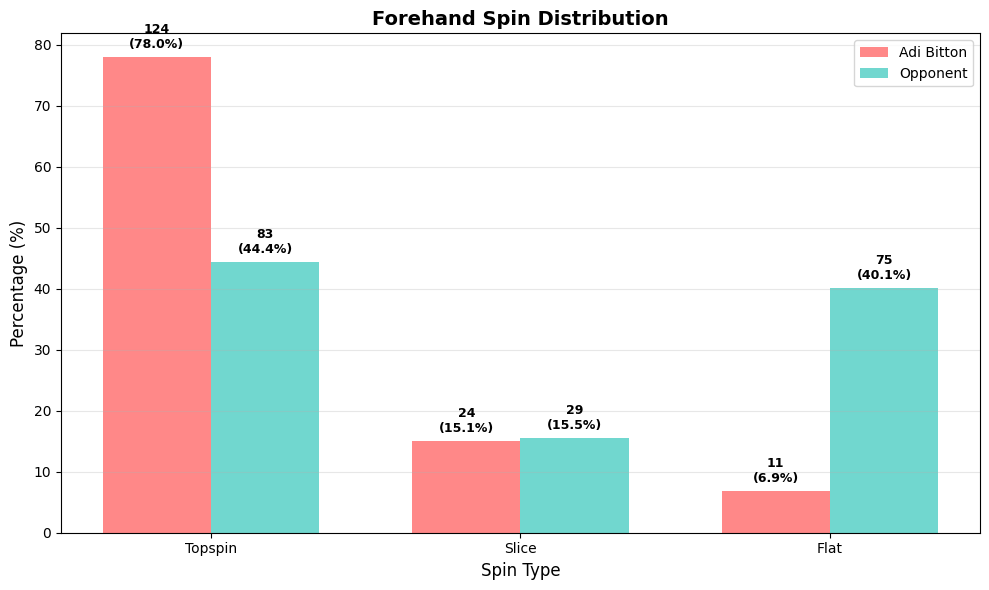

In [235]:
# @title
# Prepare spin data
spin_data = []
for player in df['Player'].unique():
    player_fh = forehand_df[forehand_df['Player'] == player]
    total_fh = len(player_fh)

    if 'Spin' in player_fh.columns:
        spin_counts = player_fh['Spin'].value_counts()
        spin_pct = (spin_counts / total_fh * 100).round(1)
        for spin in spin_counts.index:
            spin_data.append({
                'Player': player,
                'Spin': spin,
                'Count': spin_counts[spin],
                'Percentage': spin_pct[spin]
            })

spin_df = pd.DataFrame(spin_data)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

spins = spin_df['Spin'].unique()
players = spin_df['Player'].unique()
x = np.arange(len(spins))
width = 0.35

colors = ['#FF6B6B', '#4ECDC4']  # Red and teal

for i, player in enumerate(players):
    player_data = spin_df[spin_df['Player'] == player].set_index('Spin').reindex(spins, fill_value=0)
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, player_data['Percentage'], width, label=player,
                   alpha=0.8, color=colors[i])

    # Add labels on bars
    for j, (idx, row) in enumerate(player_data.iterrows()):
        if row['Percentage'] > 0:
            count = int(row['Count']) if 'Count' in row else ''
            pct = row['Percentage']
            ax.text(j + offset, row['Percentage'] + 1, f'{count}\n({pct}%)',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Spin Type', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Forehand Spin Distribution', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(spins, rotation=0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

##Direction

In [236]:
# @title
 # Direction distribution
for player in df['Player'].unique():
    player_fh = forehand_df[forehand_df['Player'] == player]
    total_fh = len(player_fh)
    print(f"\n{player}")

    if 'Direction' in player_fh.columns:
        dir_dist = player_fh['Direction'].value_counts()
        dir_pct = (dir_dist / total_fh * 100).round(1)

        print("\nDirection Distribution:")
        for direction, count in dir_dist.items():
            print(f"  {direction:15} {count} ({dir_pct[direction]}%)")


Adi Bitton

Direction Distribution:
  cross court     75 (47.2%)
  down the line   55 (34.6%)
  inside in       20 (12.6%)
  inside out      9 (5.7%)

Opponent

Direction Distribution:
  down the line   80 (42.8%)
  cross court     67 (35.8%)
  inside in       21 (11.2%)
  inside out      19 (10.2%)


###Visual Direction

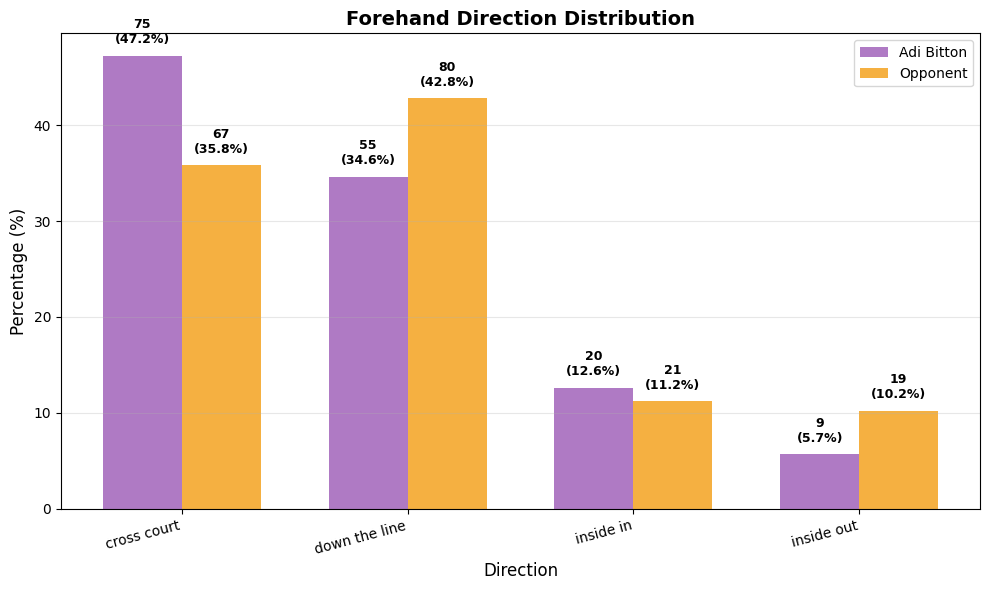

In [237]:
# @title
# Prepare direction data
direction_data = []
for player in df['Player'].unique():
    player_fh = forehand_df[forehand_df['Player'] == player]
    total_fh = len(player_fh)

    if 'Direction' in player_fh.columns:
        dir_counts = player_fh['Direction'].value_counts()
        dir_pct = (dir_counts / total_fh * 100).round(1)
        for direction in dir_counts.index:
            direction_data.append({
                'Player': player,
                'Direction': direction,
                'Count': dir_counts[direction],
                'Percentage': dir_pct[direction]
            })

direction_df = pd.DataFrame(direction_data)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

directions = direction_df['Direction'].unique()
players = direction_df['Player'].unique()
x = np.arange(len(directions))
width = 0.35

colors = ['#9B59B6', '#F39C12']  # Purple and orange

for i, player in enumerate(players):
    player_data = direction_df[direction_df['Player'] == player].set_index('Direction').reindex(directions, fill_value=0)
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, player_data['Percentage'], width, label=player,
                   alpha=0.8, color=colors[i])

    # Add labels on bars
    for j, (idx, row) in enumerate(player_data.iterrows()):
        if row['Percentage'] > 0:
            count = int(row['Count']) if 'Count' in row else ''
            pct = row['Percentage']
            ax.text(j + offset, row['Percentage'] + 1, f'{count}\n({pct}%)',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Direction', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Forehand Direction Distribution', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(directions, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#Backhand

In [238]:
# @title
# Backhand distribution by Spin and Direction for each player
backhand_df = df[df['Stroke'] == 'Backhand']

for player in df['Player'].unique():
    player_bh = backhand_df[backhand_df['Player'] == player]
    total_bh = len(player_bh)

    print(f"\n{player} (Total Backhands: {total_bh})")
    print("-" * 40)

    # Spin distribution
    if 'Spin' in player_bh.columns:
        spin_dist = player_bh['Spin'].value_counts()
        spin_pct = (spin_dist / total_bh * 100).round(1)

        print("\nSpin Distribution:")
        for spin, count in spin_dist.items():
            print(f"  {spin:15} {count} ({spin_pct[spin]}%)")

    # Direction distribution
    if 'Direction' in player_bh.columns:
        dir_dist = player_bh['Direction'].value_counts()
        dir_pct = (dir_dist / total_bh * 100).round(1)

        print("\nDirection Distribution:")
        for direction, count in dir_dist.items():
            print(f"  {direction:15} {count} ({dir_pct[direction]}%)")


Adi Bitton (Total Backhands: 162)
----------------------------------------

Spin Distribution:
  Flat            71 (43.8%)
  Topspin         69 (42.6%)
  Slice           22 (13.6%)

Direction Distribution:
  cross court     72 (44.4%)
  down the line   61 (37.7%)
  inside in       16 (9.9%)
  inside out      13 (8.0%)

Opponent (Total Backhands: 127)
----------------------------------------

Spin Distribution:
  Topspin         85 (66.9%)
  Flat            35 (27.6%)
  Slice           7 (5.5%)

Direction Distribution:
  cross court     70 (55.1%)
  down the line   41 (32.3%)
  inside in       13 (10.2%)
  inside out      3 (2.4%)


## Visual Spin

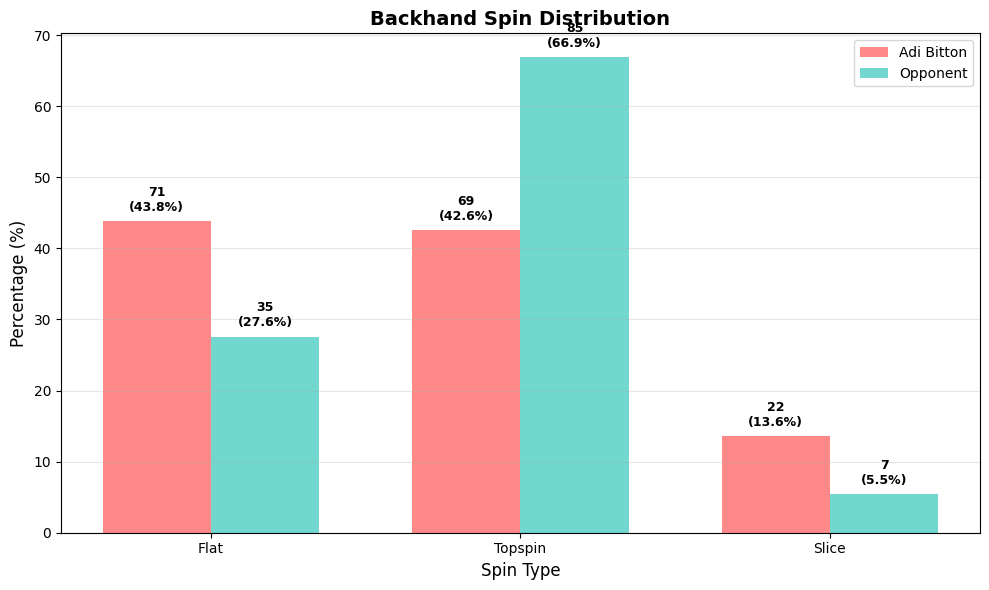

In [239]:
# @title

# Prepare spin data
spin_data = []
for player in df['Player'].unique():
    player_bh = backhand_df[backhand_df['Player'] == player]
    total_bh = len(player_bh)

    if 'Spin' in player_bh.columns:
        spin_counts = player_bh['Spin'].value_counts()
        spin_pct = (spin_counts / total_bh * 100).round(1)
        for spin in spin_counts.index:
            spin_data.append({
                'Player': player,
                'Spin': spin,
                'Count': spin_counts[spin],
                'Percentage': spin_pct[spin]
            })

spin_df = pd.DataFrame(spin_data)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

spins = spin_df['Spin'].unique()
players = spin_df['Player'].unique()
x = np.arange(len(spins))
width = 0.35

colors = ['#FF6B6B', '#4ECDC4']

for i, player in enumerate(players):
    player_data = spin_df[spin_df['Player'] == player].set_index('Spin').reindex(spins, fill_value=0)
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, player_data['Percentage'], width, label=player,
                   alpha=0.8, color=colors[i])

    # Add labels on bars
    for j, (idx, row) in enumerate(player_data.iterrows()):
        if row['Percentage'] > 0:
            count = int(row['Count']) if 'Count' in row else ''
            pct = row['Percentage']
            ax.text(j + offset, row['Percentage'] + 1, f'{count}\n({pct}%)',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Spin Type', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Backhand Spin Distribution', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(spins, rotation=0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

###Visual Direction

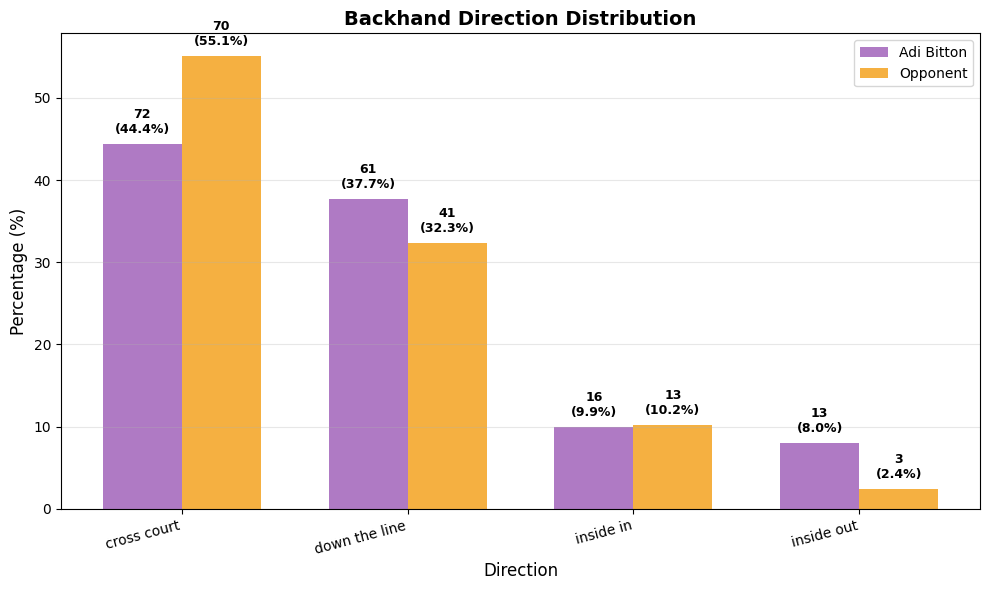

In [240]:
# @title
# Prepare direction data
direction_data = []
for player in df['Player'].unique():
    player_bh = backhand_df[backhand_df['Player'] == player]
    total_bh = len(player_bh)

    if 'Direction' in player_bh.columns:
        dir_counts = player_bh['Direction'].value_counts()
        dir_pct = (dir_counts / total_bh * 100).round(1)
        for direction in dir_counts.index:
            direction_data.append({
                'Player': player,
                'Direction': direction,
                'Count': dir_counts[direction],
                'Percentage': dir_pct[direction]
            })

direction_df = pd.DataFrame(direction_data)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

directions = direction_df['Direction'].unique()
players = direction_df['Player'].unique()
x = np.arange(len(directions))
width = 0.35

colors = ['#9B59B6', '#F39C12']  # Purple and orange

for i, player in enumerate(players):
    player_data = direction_df[direction_df['Player'] == player].set_index('Direction').reindex(directions, fill_value=0)
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, player_data['Percentage'], width, label=player,
                   alpha=0.8, color=colors[i])

    # Add labels on bars
    for j, (idx, row) in enumerate(player_data.iterrows()):
        if row['Percentage'] > 0:
            count = int(row['Count']) if 'Count' in row else ''
            pct = row['Percentage']
            ax.text(j + offset, row['Percentage'] + 1, f'{count}\n({pct}%)',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Direction', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Backhand Direction Distribution', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(directions, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#Serve/Return and one

In [241]:
# @title
# =========================
# COMBINED CHUNK — Functions + Data Processing
# =========================
import pandas as pd

def add_point_id(df, key_cols=("Set", "Game", "Point")):
    """Create a robust unique point id using available key columns."""
    df = df.copy()
    use_cols = [c for c in key_cols if c in df.columns]
    if not use_cols:
        raise KeyError("No point key columns found. Need at least one of: Set, Game, Point.")
    df["_point_id"] = df[use_cols].astype(str).agg("-".join, axis=1)
    return df

def normalize_side_from_hit_zone(hit_zone):
    """Map Hit Zone to Deuce/Ad where possible; otherwise Unknown."""
    s = str(hit_zone).strip().lower()
    if s.startswith("deuce"):
        return "Deuce"
    if s.startswith("ad"):
        return "Ad"
    return "Unknown"

def fmt_record(won, total):
    """Format as W/T (PCT%)."""
    pct = round((won / total) * 100, 1) if total else 0
    return f"{int(won)}/{int(total)} ({pct}%)"

def two_shot_point_df_by_role(df, anchor_type, plus_one_type, hit_zone_col="Hit Zone"):
    """
    Returns a DataFrame with one row per qualifying point:
    - _point_id
    - Player (the focal player)
    - Side (Deuce/Ad from Hit Zone)
    - Won (boolean)
    """
    if "_point_id" not in df.columns:
        raise KeyError("Run add_point_id(df) first.")
    if hit_zone_col not in df.columns:
        raise KeyError(f"Missing '{hit_zone_col}' column.")

    def qualifies_point(g):
        anchor = g[g["Type"] == anchor_type]
        if len(anchor) != 1:
            return False
        focal_player = anchor["Player"].iloc[0]
        focal_rows = g[g["Player"] == focal_player]
        return (len(focal_rows) == 2) and (set(focal_rows["Type"]) == {anchor_type, plus_one_type})

    pts = df.groupby("_point_id", group_keys=False).filter(qualifies_point)

    rows = []
    for pid, g in pts.groupby("_point_id"):
        anchor_row = g.loc[g["Type"] == anchor_type].iloc[0]
        focal_player = anchor_row["Player"]
        side = normalize_side_from_hit_zone(anchor_row[hit_zone_col])
        winner = g["Winner"].iloc[0]
        rows.append({
            "_point_id": pid,
            "Player": focal_player,
            "Side": side,
            "Won": (winner == focal_player)
        })

    return pd.DataFrame(rows)

def two_shot_table_by_role(df, anchor_type, plus_one_type, role_label, hit_zone_col="Hit Zone"):
    """
    Build a per-player table for 2-shot points where the focal player (server/returner)
    has exactly two shots: {anchor_type, plus_one_type}.

    Side (Deuce/Ad) is derived from the focal player's Hit Zone on the anchor shot row.
    """
    if "_point_id" not in df.columns:
        raise KeyError("df must include '_point_id'. Run add_point_id(df) first.")

    # Get point-level data
    point_df = two_shot_point_df_by_role(df, anchor_type, plus_one_type, hit_zone_col)

    players = sorted(df["Player"].dropna().unique())
    if point_df.empty:
        return pd.DataFrame({"Player": players})

    # Player-level aggregation
    rows = []
    for p in players:
        pp = point_df[point_df["Player"] == p]
        dd = pp[pp["Side"] == "Deuce"]
        aa = pp[pp["Side"] == "Ad"]
        rows.append({
            "Player": p,
            f"{role_label} (All)":   fmt_record(pp["Won"].sum(), len(pp)),
            f"{role_label} (Deuce)": fmt_record(dd["Won"].sum(), len(dd)),
            f"{role_label} (Ad)":    fmt_record(aa["Won"].sum(), len(aa)),
        })

    return pd.DataFrame(rows)

# =========================
# DATA PROCESSING
# =========================
df = add_point_id(df)

# Create serve_points DataFrame
serve_points = two_shot_point_df_by_role(
    df,
    anchor_type="first_serve",
    plus_one_type="serve_plus_one",
    hit_zone_col="Hit Zone"
)

# Create return_points DataFrame
return_points = two_shot_point_df_by_role(
    df,
    anchor_type="first_return",
    plus_one_type="return_plus_one",
    hit_zone_col="Hit Zone"
)

##Summary and Graph

In [242]:
# @title

# Table 1: Serve +1 (first_serve + serve_plus_one)
serve_plus_one_df = two_shot_table_by_role(
    df,
    anchor_type="first_serve",
    plus_one_type="serve_plus_one",
    role_label="Serve+1",
    hit_zone_col="Hit Zone"
)

# Table 2: Return +1 (first_return + return_plus_one)
return_plus_one_df = two_shot_table_by_role(
    df,
    anchor_type="first_return",
    plus_one_type="return_plus_one",
    role_label="Return+1",
    hit_zone_col="Hit Zone"
)

print("=== Serve Plus 1 ===")
print(serve_plus_one_df.to_string(index=False))

print("\n=== Return Plus 1 ===")
print(return_plus_one_df.to_string(index=False))


=== Serve Plus 1 ===
    Player Serve+1 (All) Serve+1 (Deuce) Serve+1 (Ad)
Adi Bitton 10/20 (50.0%)    6/13 (46.2%)  4/7 (57.1%)
  Opponent  7/16 (43.8%)     2/6 (33.3%) 5/10 (50.0%)

=== Return Plus 1 ===
    Player Return+1 (All) Return+1 (Deuce) Return+1 (Ad)
Adi Bitton   6/11 (54.5%)      4/6 (66.7%)   2/5 (40.0%)
  Opponent   6/12 (50.0%)      5/7 (71.4%)   1/5 (20.0%)


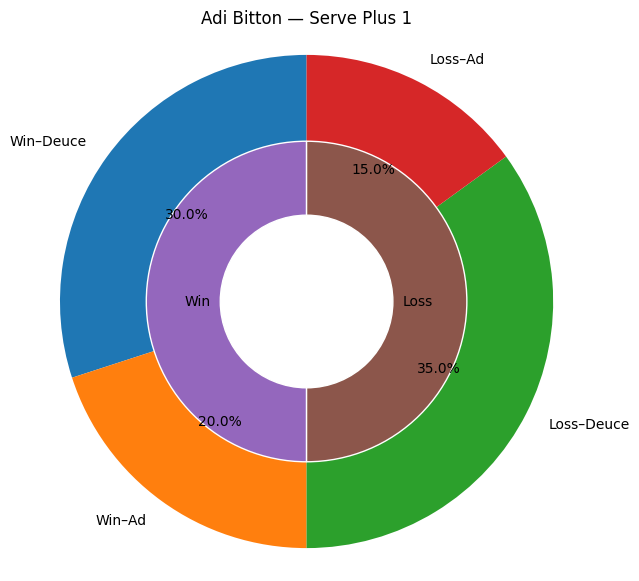

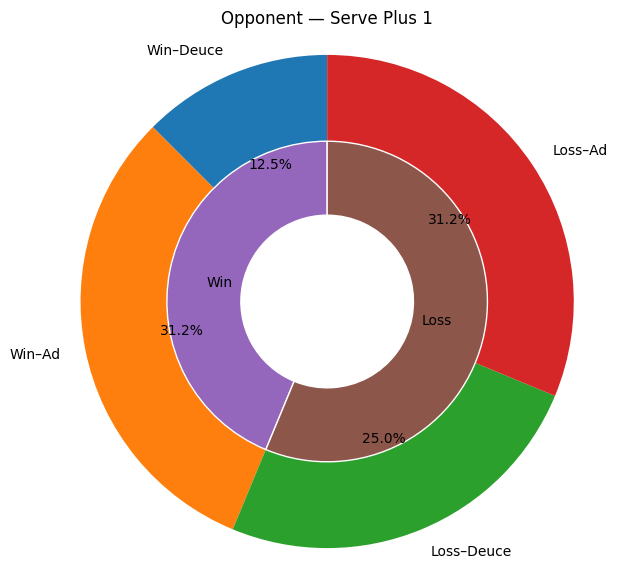

In [243]:
# @title
# =========================
# PLOT-ONLY (PRINT/SHOW ONLY) — no saving
# Assumes you already created: serve_points and/or return_points
# =========================
import matplotlib.pyplot as plt

def _counts_2x2(point_df, player, drop_unknown=True):
    d = point_df[point_df["Player"] == player].copy()
    if d.empty:
        return None
    if drop_unknown:
        d = d[d["Side"].isin(["Deuce", "Ad"])]
    if d.empty:
        return None

    return {
        "win_deuce":  int(((d["Won"] == True)  & (d["Side"] == "Deuce")).sum()),
        "win_ad":     int(((d["Won"] == True)  & (d["Side"] == "Ad")).sum()),
        "loss_deuce": int(((d["Won"] == False) & (d["Side"] == "Deuce")).sum()),
        "loss_ad":    int(((d["Won"] == False) & (d["Side"] == "Ad")).sum()),
    }

def plot_winloss_deucead_pie(point_df, player, title=None, drop_unknown=True):
    """
    Two-ring pie (donut):
      inner ring: Win vs Loss
      outer ring: Win–Deuce, Win–Ad, Loss–Deuce, Loss–Ad
    """
    c = _counts_2x2(point_df, player, drop_unknown=drop_unknown)
    if c is None:
        print(f"[skip] {player}: no qualifying Deuce/Ad points.")
        return

    outer_sizes = [c["win_deuce"], c["win_ad"], c["loss_deuce"], c["loss_ad"]]
    if sum(outer_sizes) == 0:
        print(f"[skip] {player}: counts are all zero.")
        return

    inner_sizes = [c["win_deuce"] + c["win_ad"], c["loss_deuce"] + c["loss_ad"]]

    outer_labels = ["Win–Deuce", "Win–Ad", "Loss–Deuce", "Loss–Ad"]
    inner_labels = ["Win", "Loss"]

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.pie(
        outer_sizes,
        radius=1.0,
        labels=outer_labels,
        autopct=lambda p: f"{p:.1f}%" if p > 0 else "",
        startangle=90
    )

    ax.pie(
        inner_sizes,
        radius=0.65,
        labels=inner_labels,
        labeldistance=0.6,
        startangle=90,
        wedgeprops=dict(width=0.30, edgecolor="white")
    )

    centre_circle = plt.Circle((0, 0), 0.35, fc="white")
    ax.add_artist(centre_circle)

    ax.set_title(title if title else f"{player}: Win/Loss × Deuce/Ad")
    ax.axis("equal")
    plt.show()

# ---- Choose which dataset to plot ----
point_df_to_plot = serve_points   # or: return_points

for p in sorted(point_df_to_plot["Player"].dropna().unique()):
    plot_winloss_deucead_pie(
        point_df_to_plot,
        player=p,
        title=f"{p} — Serve Plus 1",
        drop_unknown=True
    )





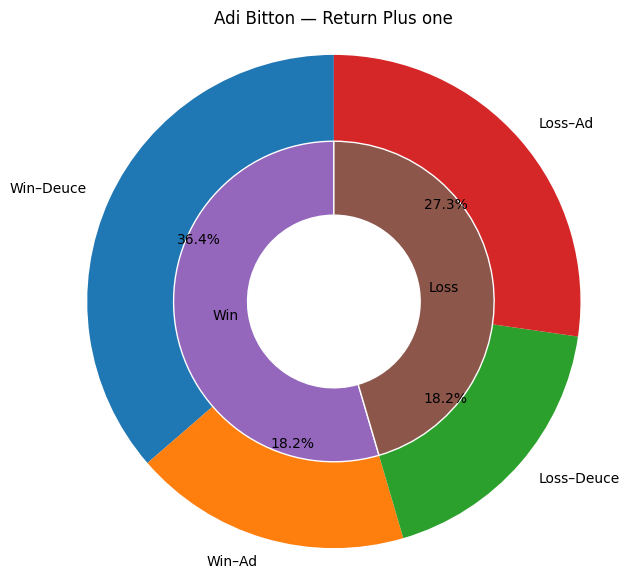

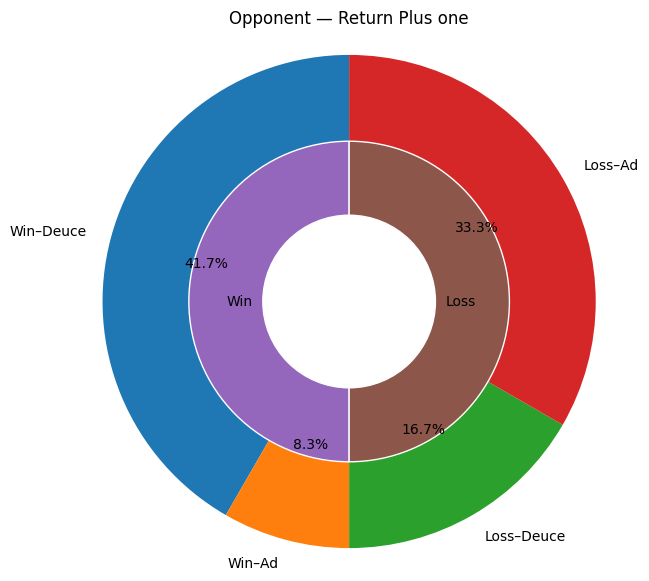

In [244]:
# @title
# ---- Choose which dataset to plot ----
point_df_to_plot = return_points   # or: return_points

for p in sorted(point_df_to_plot["Player"].dropna().unique()):
    plot_winloss_deucead_pie(
        point_df_to_plot,
        player=p,
        title=f"{p} — Return Plus one",
        drop_unknown=True
    )


#Court View

x = 0 is middle of the baseline
y = 0 is baseline, y = 11.885 is net

#Hit position

In [245]:
# @title
# Court dimensions (in meters)
Y_NEAR = 0
Y_NET = 11.885
Y_FAR = 23.77

X_SINGLES = 4.115
X_DOUBLES = 5.485

SERVICE_TO_NET = 6.40
Y_NEAR_SERVICE = Y_NET - SERVICE_TO_NET
Y_FAR_SERVICE = Y_NET + SERVICE_TO_NET

CENTER_MARK_LEN = 0.20

EXTRA_BEHIND_BASELINE = 3
Y_PLOT_MIN = Y_NEAR - EXTRA_BEHIND_BASELINE
Y_PLOT_MAX = Y_FAR + EXTRA_BEHIND_BASELINE
def draw_half_tennis_court(data_df, player=None, point=None, shot=None, type_shot=None,
                           stroke=None, spin=None, hit_zone=None, result=None,
                           direction=None, winner=None, title_suffix=""):

    # Start with full dataset
    filtered_df = data_df.copy()

    # Apply filters
    if player is not None:
        filtered_df = filtered_df[filtered_df['Player'] == player]

    if point is not None:
        filtered_df = filtered_df[filtered_df['Point'] == point]

    if shot is not None:
        filtered_df = filtered_df[filtered_df['Shot'] == shot]

    if type_shot is not None:
        filtered_df = filtered_df[filtered_df['Type'] == type_shot]

    if stroke is not None:
        filtered_df = filtered_df[filtered_df['Stroke'] == stroke]

    if spin is not None:
        filtered_df = filtered_df[filtered_df['Spin'] == spin]

    if hit_zone is not None:
        filtered_df = filtered_df[filtered_df['Hit Zone'] == hit_zone]

    if result is not None:
        filtered_df = filtered_df[filtered_df['Result'] == result]

    if direction is not None:
        filtered_df = filtered_df[filtered_df['Direction'] == direction]

    if winner is not None:
        filtered_df = filtered_df[filtered_df['Winner'] == winner]

    # Get hit data using standardized coordinates
    hit_data = filtered_df[['hit_x_std', 'hit_y_std']].dropna()

    # Create figure (half court - narrower, taller to accommodate -4 to net)
    fig, ax = plt.subplots(figsize=(6, 14))

    # Draw half court outline (baseline at y=0, net at y=11.885, x=0 is center)
    # Singles sidelines
    ax.plot([-X_SINGLES, -X_SINGLES], [0, Y_NET], 'k-', linewidth=2)
    ax.plot([X_SINGLES, X_SINGLES], [0, Y_NET], 'k-', linewidth=2)

    # Doubles sidelines (alley)
    ax.plot([-X_DOUBLES, -X_DOUBLES], [0, Y_NET], 'k-', linewidth=1.5, linestyle='--')
    ax.plot([X_DOUBLES, X_DOUBLES], [0, Y_NET], 'k-', linewidth=1.5, linestyle='--')

    # Baseline (y=0)
    ax.plot([-X_DOUBLES, X_DOUBLES], [0, 0], 'k-', linewidth=2)

    # Net (y=11.885)
    ax.plot([-X_DOUBLES, X_DOUBLES], [Y_NET, Y_NET], 'k-', linewidth=2)

    # Service line
    ax.plot([-X_SINGLES, X_SINGLES], [Y_NEAR_SERVICE, Y_NEAR_SERVICE], 'k-', linewidth=1.5)

    # Center service line
    ax.plot([0, 0], [Y_NEAR_SERVICE, Y_NET], 'k-', linewidth=1.5)

    # Center mark at baseline
    ax.plot([0, 0], [0, -CENTER_MARK_LEN], 'k-', linewidth=1.5)

    # Plot filtered hit positions using standardized coordinates
    ax.scatter(hit_data['hit_x_std'], hit_data['hit_y_std'],
               c='blue', alpha=0.5, s=30, edgecolors='darkblue', linewidth=0.5,
               label='Hit Positions')

    # Set axis properties - extended to show -4 in y
    ax.set_xlim(-X_DOUBLES - 0.5, X_DOUBLES + 0.5)
    ax.set_ylim(-4, Y_NET + 1)
    ax.set_aspect('equal')
    ax.set_xlabel('Court Width (m)', fontsize=12)
    ax.set_ylabel('Court Length (m)', fontsize=12)

    # Build title based on filters
    title_parts = ['Half Court - Hit Positions (Standardized)']
    if player: title_parts.append(f'Player: {player}')
    if point is not None: title_parts.append(f'Point: {point}')
    if shot is not None: title_parts.append(f'Shot: {shot}')
    if type_shot: title_parts.append(f'Type: {type_shot}')
    if stroke: title_parts.append(f'Stroke: {stroke}')
    if spin: title_parts.append(f'Spin: {spin}')
    if hit_zone: title_parts.append(f'Zone: {hit_zone}')
    if result: title_parts.append(f'Result: {result}')
    if direction: title_parts.append(f'Direction: {direction}')
    if winner: title_parts.append(f'Winner: {winner}')
    if title_suffix: title_parts.append(title_suffix)

    ax.set_title('\n'.join(title_parts), fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend()

    plt.tight_layout()
    plt.show()
def show_available_values(data_df):
    """Display all available filter values in the dataset"""
    print("=== Available Filter Values ===")
    print(f"Players: {sorted(data_df['Player'].unique())}")
    print(f"Types: {sorted(data_df['Type'].dropna().unique())}")
    print(f"Strokes: {sorted(data_df['Stroke'].dropna().unique())}")
    print(f"Spins: {sorted(data_df['Spin'].dropna().unique())}")
    print(f"Hit Zones: {sorted(data_df['Hit Zone'].dropna().unique())}")
    print(f"Results: {sorted(data_df['Result'].dropna().unique())}")
    print(f"Directions: {sorted(data_df['Direction'].dropna().unique())}")
    print(f"Winners: {sorted(data_df['Winner'].dropna().unique())}")
    print(f"Point range: {data_df['Point'].min()} to {data_df['Point'].max()}")
    print(f"Shot range: {data_df['Shot'].min()} to {data_df['Shot'].max()}")

=== Available Filter Values ===
Players: ['Adi Bitton', 'Opponent']
Types: ['first_return', 'first_serve', 'in_play', 'return_plus_one', 'second_return', 'second_serve', 'serve_plus_one']
Strokes: ['Backhand', 'Forehand', 'Overhead', 'Serve', 'Volley']
Spins: ['Flat', 'Kick', 'Slice', 'Topspin']
Hit Zones: ['ad', 'ad_alley', 'center_line', 'deuce', 'deuce_alley', 'deuce_out']
Results: ['In', 'Net', 'Out']
Directions: ['---', 'cross court', 'down the T', 'down the line', 'inside in', 'inside out', 'out wide']
Winners: ['Adi Bitton', 'Opponent']
Point range: 1 to 166
Shot range: 1 to 18


/tmp/ipython-input-295821424.py:69: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot([-X_DOUBLES, -X_DOUBLES], [0, Y_NET], 'k-', linewidth=1.5, linestyle='--')
/tmp/ipython-input-295821424.py:70: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot([X_DOUBLES, X_DOUBLES], [0, Y_NET], 'k-', linewidth=1.5, linestyle='--')


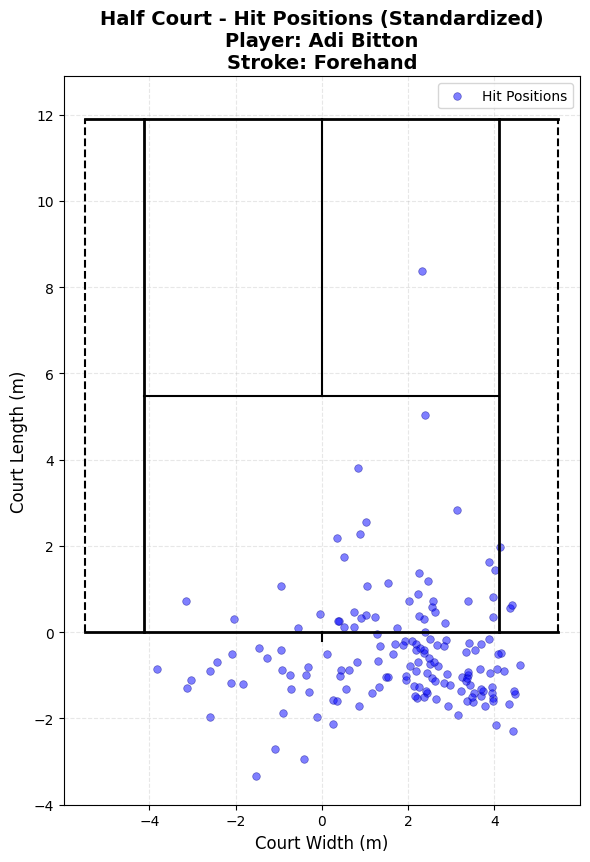

In [252]:
show_available_values(df)
# Show all standardized hit positions on half court
#draw_half_tennis_court(df)

# Show only Adi's forehands
draw_half_tennis_court(df, player='Adi Bitton', stroke='Forehand')

# Show cross court winners
#draw_half_tennis_court(df, direction='cross court', winner='Adi Bitton')

##Bounce Position

In [247]:
# @title
def draw_half_court_bounce(data_df, player=None, point=None, shot=None, type_shot=None,
                           stroke=None, spin=None, bounce_zone=None, result=None,
                           direction=None, winner=None, title_suffix=""):
    """
    Draw half tennis court with filtered bounce positions using standardized coordinates.
    Any bounce y > net is capped at net line.
    """

    # Start with full dataset
    filtered_df = data_df.copy()

    # Apply all filters (same as before)
    if player is not None:
        filtered_df = filtered_df[filtered_df['Player'] == player]
    if point is not None:
        filtered_df = filtered_df[filtered_df['Point'] == point]
    if shot is not None:
        filtered_df = filtered_df[filtered_df['Shot'] == shot]
    if type_shot is not None:
        filtered_df = filtered_df[filtered_df['Type'] == type_shot]
    if stroke is not None:
        filtered_df = filtered_df[filtered_df['Stroke'] == stroke]
    if spin is not None:
        filtered_df = filtered_df[filtered_df['Spin'] == spin]
    if bounce_zone is not None:
        filtered_df = filtered_df[filtered_df['Bounce Zone'] == bounce_zone]
    if result is not None:
        filtered_df = filtered_df[filtered_df['Result'] == result]
    if direction is not None:
        filtered_df = filtered_df[filtered_df['Direction'] == direction]
    if winner is not None:
        filtered_df = filtered_df[filtered_df['Winner'] == winner]

    # Get bounce data and ensure numeric types
    bounce_data = filtered_df[['bounce_x_std', 'bounce_y_std']].copy()
    bounce_data['bounce_x_std'] = pd.to_numeric(bounce_data['bounce_x_std'], errors='coerce')
    bounce_data['bounce_y_std'] = pd.to_numeric(bounce_data['bounce_y_std'], errors='coerce')
    bounce_data = bounce_data.dropna()

    # Cap y at net line
    bounce_data['bounce_y_std'] = bounce_data['bounce_y_std'].clip(upper=Y_NET)

    # Create figure
    fig, ax = plt.subplots(figsize=(6, 14))

    # Draw court lines (same as hit function)
    ax.plot([-X_SINGLES, -X_SINGLES], [0, Y_NET], 'k-', linewidth=2)
    ax.plot([X_SINGLES, X_SINGLES], [0, Y_NET], 'k-', linewidth=2)
    ax.plot([-X_DOUBLES, -X_DOUBLES], [0, Y_NET], 'k-', linewidth=1.5, linestyle='--')
    ax.plot([X_DOUBLES, X_DOUBLES], [0, Y_NET], 'k-', linewidth=1.5, linestyle='--')
    ax.plot([-X_DOUBLES, X_DOUBLES], [0, 0], 'k-', linewidth=2)
    ax.plot([-X_DOUBLES, X_DOUBLES], [Y_NET, Y_NET], 'k-', linewidth=2)
    ax.plot([-X_SINGLES, X_SINGLES], [Y_NEAR_SERVICE, Y_NEAR_SERVICE], 'k-', linewidth=1.5)
    ax.plot([0, 0], [Y_NEAR_SERVICE, Y_NET], 'k-', linewidth=1.5)
    ax.plot([0, 0], [0, -CENTER_MARK_LEN], 'k-', linewidth=1.5)

    # Plot bounce positions (different color)
    ax.scatter(bounce_data['bounce_x_std'], bounce_data['bounce_y_std'],
               c='red', alpha=0.5, s=30, edgecolors='darkred', linewidth=0.5,
               label='Bounce Positions')

    # Set axis properties
    ax.set_xlim(-X_DOUBLES - 0.5, X_DOUBLES + 0.5)
    ax.set_ylim(-4, Y_NET + 1)
    ax.set_aspect('equal')
    ax.set_xlabel('Court Width (m)', fontsize=12)
    ax.set_ylabel('Court Length (m)', fontsize=12)

    # Build title
    title_parts = ['Half Court - Bounce Positions (Standardized)']
    if player: title_parts.append(f'Player: {player}')
    if point is not None: title_parts.append(f'Point: {point}')
    if shot is not None: title_parts.append(f'Shot: {shot}')
    if type_shot: title_parts.append(f'Type: {type_shot}')
    if stroke: title_parts.append(f'Stroke: {stroke}')
    if spin: title_parts.append(f'Spin: {spin}')
    if bounce_zone: title_parts.append(f'Zone: {bounce_zone}')
    if result: title_parts.append(f'Result: {result}')
    if direction: title_parts.append(f'Direction: {direction}')
    if winner: title_parts.append(f'Winner: {winner}')
    if title_suffix: title_parts.append(title_suffix)

    ax.set_title('\n'.join(title_parts), fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend()

    plt.tight_layout()
    plt.show()

/tmp/ipython-input-1473846840.py:50: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot([-X_DOUBLES, -X_DOUBLES], [0, Y_NET], 'k-', linewidth=1.5, linestyle='--')
/tmp/ipython-input-1473846840.py:51: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot([X_DOUBLES, X_DOUBLES], [0, Y_NET], 'k-', linewidth=1.5, linestyle='--')


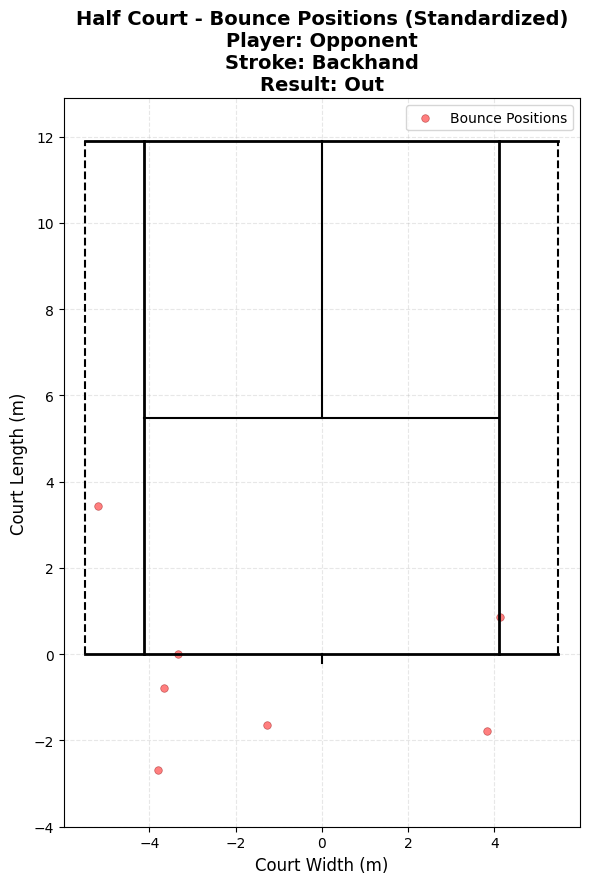

In [248]:

# Show all bounces
#draw_half_court_bounce(df)

# Show opponent's bounce positions
draw_half_court_bounce(df, player='Opponent', result='Out', stroke='Backhand')

# Show forehand bounces
#draw_half_court_bounce(df, stroke='Forehand')

#Distance

In [253]:

def calculate_distance(x1, y1, x2, y2):
    """Euclidean distance between two points."""
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

def add_distance_within_point(
    df,
    group_cols=("Point", "Player"),
    x_col="hit_x_std",
    y_col="hit_y_std",
    out_col="distance"
):
    # Basic checks
    missing = [c for c in (*group_cols, x_col, y_col) if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    d = df.copy()

    # Ensure numeric coords
    d[x_col] = pd.to_numeric(d[x_col], errors="coerce")
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")

    # Preserve the original chronological order in the file
    d["_row_order"] = np.arange(len(d))

    # Sort so shift() is correct
    d = d.sort_values(list(group_cols) + ["_row_order"])

    # Previous position within SAME (Set,Game,Point,Player)
    g = d.groupby(list(group_cols), sort=False)
    prev_x = g[x_col].shift(1)
    prev_y = g[y_col].shift(1)

    d[out_col] = calculate_distance(prev_x, prev_y, d[x_col], d[y_col])

    return d.drop(columns=["_row_order"])

def print_player_distance_summary(df_with_dist, player_col="Player", dist_col="distance"):
    summary = (df_with_dist
               .groupby(player_col)[dist_col]
               .agg(avg_distance="mean", total_distance="sum")
               .sort_values("total_distance", ascending=False))

    # Pretty print
    print("Movement summary:")
    print(summary.round({"avg_distance": 1, "total_distance": 1}))
    return summary


# ===== Run on your dataframe df =====
df_dist = add_distance_within_point(df)
summary = print_player_distance_summary(df_dist)

#df_dist[df_dist["Player"] == "Adi Bitton"][["Point","Shot","hit_x_std","hit_y_std","distance"]].head(20)


Movement summary:
            avg_distance  total_distance
Player                                  
Opponent             3.0           854.3
Adi Bitton           2.7           756.5


#Moved Inside Service Box

In [268]:
import numpy as np
import pandas as pd

# ========= helper formatting =========
def fmt_made(made, total):
    if total == 0:
        return "0/0 —"
    pct = 100 * made / total
    return f"{int(made)}/{int(total)} {pct:.1f}%"

def pct_from_str(s):
    try:
        return float(str(s).split()[-1].replace("%", ""))
    except Exception:
        return np.nan

def summarize_region(df, mask, colname):
    tmp = df.loc[mask, ["Player", "Result"]].copy()
    tmp["made"] = (tmp["Result"] == "In")

    s = (tmp.groupby("Player")["made"]
           .agg(made="sum", total="count")
           .reset_index())

    s[colname] = [fmt_made(m, t) for m, t in zip(s["made"], s["total"])]
    return s[["Player", colname]]

# ========= coordinate columns =========
X = df["hit_x_std"]
Y = df["hit_y_std"]
made_mask = (df["Result"] == "In")

# ========= region masks (HIT positions) =========
# 1) Service box (near): y in [Y_NEAR_SERVICE, Y_NET], |x| <= X_SINGLES
mask_service_box = (
    X.notna() & Y.notna() &
    (Y >= Y_NEAR_SERVICE) & (Y <= Y_NET) &
    (X.abs() <= X_SINGLES)
)

# 2) Baseline area (near): y in [Y_NEAR, Y_NEAR_SERVICE), |x| <= X_SINGLES
mask_baseline_area = (
    X.notna() & Y.notna() &
    (Y >= Y_NEAR) & (Y < Y_NEAR_SERVICE) &
    (X.abs() <= X_SINGLES)
)

# 3) Behind baseline: y < 0
mask_behind_baseline = (
    X.notna() & Y.notna() &
    (Y < Y_NEAR)
)

# 4) Outside right singles line: x > 4.115
mask_out_right_singles = (
    X.notna() & Y.notna() &
    (X > X_SINGLES)
)

# 5) Outside left singles line: x < -4.115
mask_out_left_singles = (
    X.notna() & Y.notna() &
    (X < -X_SINGLES)
)

# ========= build per-player table =========
svc   = summarize_region(df, mask_service_box, "service_box")
base  = summarize_region(df, mask_baseline_area, "baseline_area")
back  = summarize_region(df, mask_behind_baseline, "behind_baseline")
right = summarize_region(df, mask_out_right_singles, "outside_right_singles")
left  = summarize_region(df, mask_out_left_singles, "outside_left_singles")

table = svc
for t in [base, back, right, left]:
    table = pd.merge(table, t, on="Player", how="outer")

# fill missing
fill_cols = ["service_box","baseline_area","behind_baseline","outside_right_singles","outside_left_singles"]
table = table.fillna({c: "0/0 —" for c in fill_cols})

# optional sorting (by service box % then baseline %)
table["pct_service"] = table["service_box"].apply(pct_from_str)
table["pct_baseline"] = table["baseline_area"].apply(pct_from_str)
table = table.sort_values(["pct_service","pct_baseline"], ascending=[False, False], na_position="last")

# final column names to match your style
table_display = table.rename(columns={
    "service_box": "made_inside_service_box",
    "baseline_area": "made_inside_baseline",
    "behind_baseline": "made_behind_baseline",
    "outside_right_singles": "made_outside_right_singles",
    "outside_left_singles": "made_outside_left_singles",
})[[
    "Player",
    "made_inside_service_box",
    "made_inside_baseline",
    "made_behind_baseline",
    "made_outside_right_singles",
    "made_outside_left_singles",
]]

print(table_display.to_string(index=False))


    Player made_inside_service_box made_inside_baseline made_behind_baseline made_outside_right_singles made_outside_left_singles
Adi Bitton               4/5 80.0%        105/145 72.4%        226/282 80.1%                 7/10 70.0%               13/24 54.2%
  Opponent               5/9 55.6%         94/136 69.1%        234/283 82.7%                34/37 91.9%                 5/8 62.5%
